# Capstone Project: Predictive Spatial Spectrum Management in Broadband Wireless Networks

## Module 20 – Exploratory Data Analysis (EDA) & Baseline Models

**Research Question**  
How can a machine learning pipeline that forecasts user mobility patterns and classifies spatial proximity enable proactive beam alignment and orthogonal spectrum allocation in dense urban broadband wireless networks to minimize co-channel interference and maximize throughput?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score, precision_score, recall_score)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

## Following is using systentic data for baseline modeling ##

In [47]:
# The following is generate synthetic data

np.random.seed(42)
n_ues = 20
n_timesteps = 500
dt = 0.2
records = []

base_stations = [
    {"id": 0, "x": 0,   "y": 0},
    {"id": 1, "x": 450, "y": 100},
    {"id": 2, "x": 200, "y": 420}
]

for ue_id in range(n_ues):
    x = np.random.uniform(50, 750)
    y = np.random.uniform(50, 750)
    speed = np.random.uniform(1.0, 10.0)
    heading = np.random.uniform(0, 2 * np.pi)
    pause = 0.0
    target_x, target_y = x, y
    vx = vy = 0.0

    for t in range(n_timesteps):
        if pause > 0:
            pause -= dt
            vx = vy = 0.0
        else:
            dist_to_target = np.sqrt((x - target_x)**2 + (y - target_y)**2)
            if dist_to_target < 5:
                pause = np.random.uniform(1, 6)
                target_x = np.random.uniform(30, 770)
                target_y = np.random.uniform(30, 770)
                heading = np.arctan2(target_y - y, target_x - x)
            else:
                heading = np.arctan2(target_y - y, target_x - x) + np.random.normal(0, 0.05)
                vx = speed * np.cos(heading)
                vy = speed * np.sin(heading)
                x += vx * dt
                y += vy * dt

        x = np.clip(x, 10, 790)
        y = np.clip(y, 10, 790)

        # Multi-cell measurements
        rsrps = []
        for bs in base_stations:
            dist = np.sqrt((x - bs["x"])**2 + (y - bs["y"])**2) + 1e-3
            rsrp = -(28 + 22 * np.log10(dist)) + np.random.normal(0, 3.5)
            rsrps.append(rsrp)
        rsrps = np.array(rsrps)
        serving_idx = np.argmax(rsrps)
        serving_rsrp = rsrps[serving_idx]
        serving_bs = base_stations[serving_idx]

        interference = np.sum(10**(rsrps / 10)) - 10**(serving_rsrp / 10)
        sinr = 10 * np.log10(10**(serving_rsrp / 10) / (interference + 1e-12))
        rsrq = serving_rsrp - 10 * np.log10(12) + np.random.normal(-1, 1.5)

        # Doppler
        dist_to_serving = np.sqrt((x - serving_bs["x"])**2 + (y - serving_bs["y"])**2) + 1e-3
        radial_velocity = (vx * (x - serving_bs["x"]) + vy * (y - serving_bs["y"])) / dist_to_serving
        doppler_hz = (radial_velocity / 3e8) * 3.5e9

        # Beam Index (location + orientation)
        aoa = np.arctan2(y - serving_bs["y"], x - serving_bs["x"])
        relative_angle = (aoa - heading + np.pi) % (2 * np.pi) - np.pi
        beam_score = aoa + 0.35 * relative_angle
        ssb_beam_idx = int(((beam_score + np.pi) / (2 * np.pi)) * 64) % 64

        records.append({
            "ue_id": ue_id,
            "timestep": t,
            "x": round(x, 2),
            "y": round(y, 2),
            "speed_mps": round(np.sqrt(vx**2 + vy**2), 2),
            "heading_rad": round(heading, 3),
            "ssb_beam_idx": ssb_beam_idx,
            "doppler_hz": round(doppler_hz, 1),
            "rsrp_dbm": round(serving_rsrp, 2),
            "rsrq_db": round(rsrq, 2),
            "sinr_db": round(sinr, 2),
            "serving_cell": serving_idx,
            "prb_util": round(np.clip(40 + (serving_rsrp + 90)*0.7 + np.random.normal(0, 10), 5, 95), 1)
        })

df = pd.DataFrame(records)
print("Raw dataset shape:", df.shape)
df.head()


Raw dataset shape: (10000, 13)


,ue_id,timestep,x,y,speed_mps,heading_rad,ssb_beam_idx,doppler_hz,rsrp_dbm,rsrq_db,sinr_db,serving_cell,prb_util
0,0,0,312.18,715.5,0.0,-1.825,55,0.0,-85.03,-97.61,-0.26,2,37.8
1,0,1,312.18,715.5,0.0,-1.825,55,0.0,-79.67,-90.24,13.70,2,32.0
2,0,2,312.18,715.5,0.0,-1.825,55,0.0,-85.46,-100.46,4.17,2,36.9
3,0,3,312.18,715.5,0.0,-1.825,40,0.0,-80.64,-92.25,0.33,1,41.4
4,0,4,312.18,715.5,0.0,-1.825,55,0.0,-81.98,-94.72,3.58,2,35.4


In [ ]:
#Data Cleaning & Feature Engineering
print("Missing values:\n", df.isnull().sum())

# Classification target
df["high_interference"] = ((df["sinr_db"] < 5) | (df["prb_util"] > 75)).astype(int)

# Regression target (next beam)
df["target_beam_idx"] = df.groupby("ue_id")["ssb_beam_idx"].shift(-1)

# Feature engineering
df["rsrp_delta"] = df.groupby("ue_id")["rsrp_dbm"].diff()

for lag in [1, 2]:
    df[f"rsrp_lag{lag}"] = df.groupby("ue_id")["rsrp_dbm"].shift(lag)
    df[f"sinr_lag{lag}"] = df.groupby("ue_id")["sinr_db"].shift(lag)

df = df.dropna().reset_index(drop=True)

print("\nCleaned shape:", df.shape)
print("\nTarget distribution (High Interference):")
print(df["high_interference"].value_counts(normalize=True).round(3))



Missing values:
 ue_id           0
timestep        0
x               0
y               0
speed_mps       0
heading_rad     0
ssb_beam_idx    0
doppler_hz      0
rsrp_dbm        0
rsrq_db         0
sinr_db         0
serving_cell    0
prb_util        0
dtype: int64

Cleaned shape: (9940, 20)

Target distribution (High Interference):
high_interference
1    0.57
0    0.43
Name: proportion, dtype: float64


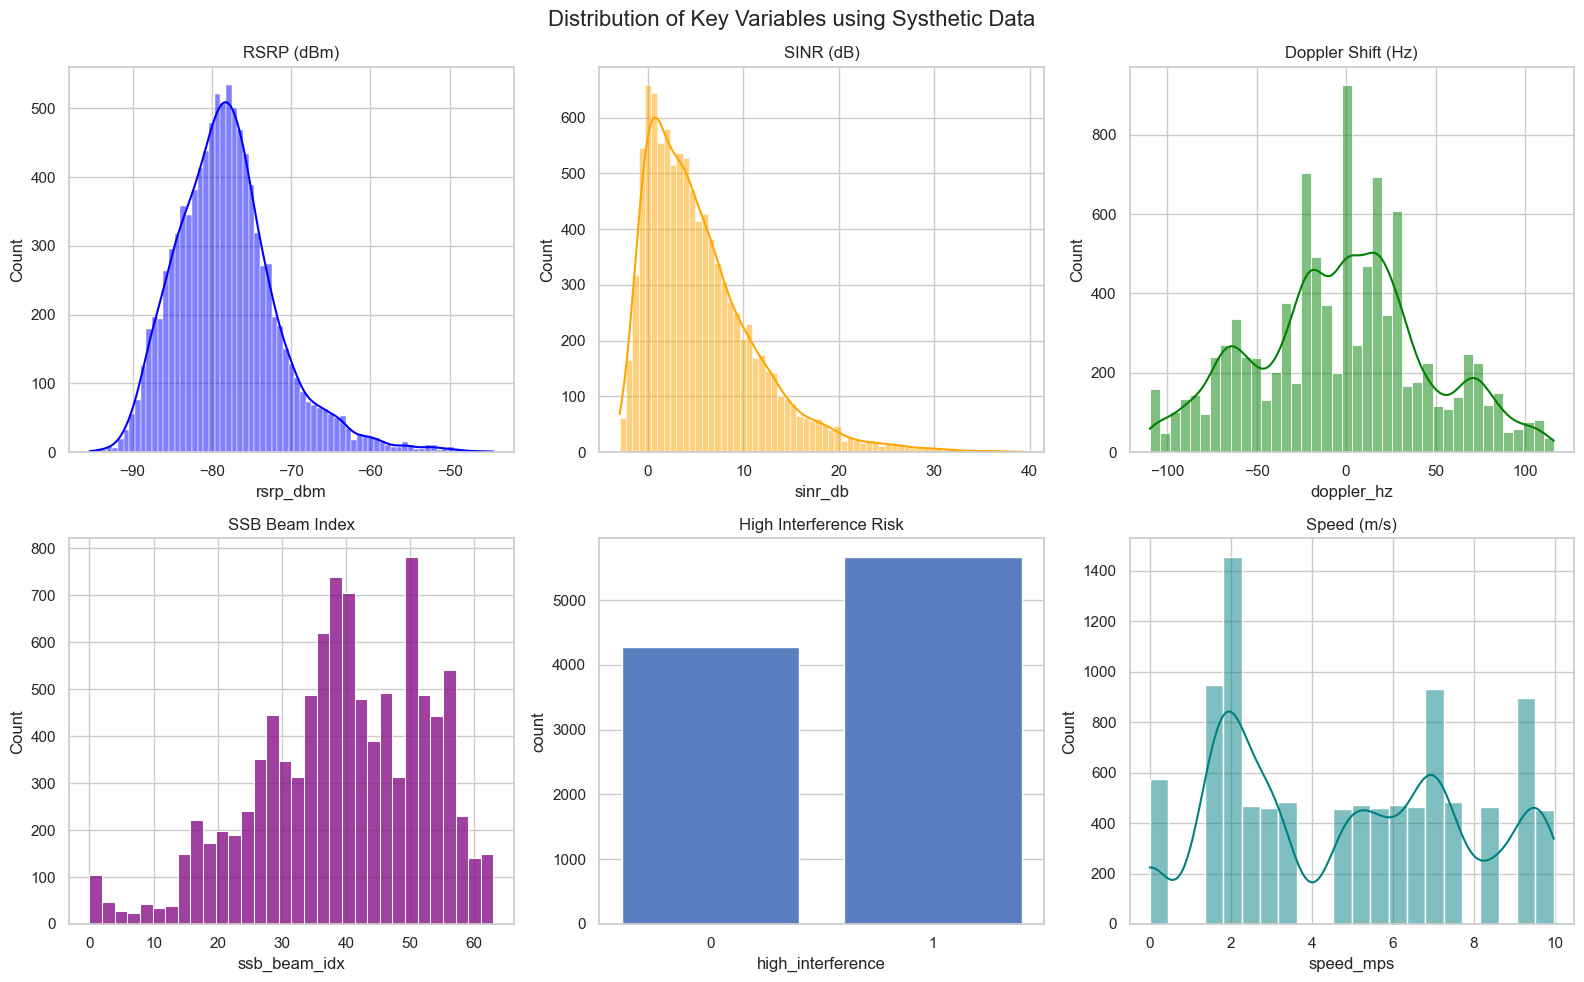

In [49]:
#EDA Visualizations

# Distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of Key Variables using Systhetic Data", fontsize=16)

sns.histplot(df["rsrp_dbm"], kde=True, ax=axes[0,0], color="blue")
axes[0,0].set_title("RSRP (dBm)")

sns.histplot(df["sinr_db"], kde=True, ax=axes[0,1], color="orange")
axes[0,1].set_title("SINR (dB)")

sns.histplot(df["doppler_hz"], kde=True, ax=axes[0,2], color="green")
axes[0,2].set_title("Doppler Shift (Hz)")

sns.histplot(df["ssb_beam_idx"], bins=32, ax=axes[1,0], color="purple")
axes[1,0].set_title("SSB Beam Index")

sns.countplot(x="high_interference", data=df, ax=axes[1,1])
axes[1,1].set_title("High Interference Risk")

sns.histplot(df["speed_mps"], kde=True, ax=axes[1,2], color="teal")
axes[1,2].set_title("Speed (m/s)")

plt.tight_layout()
plt.show()



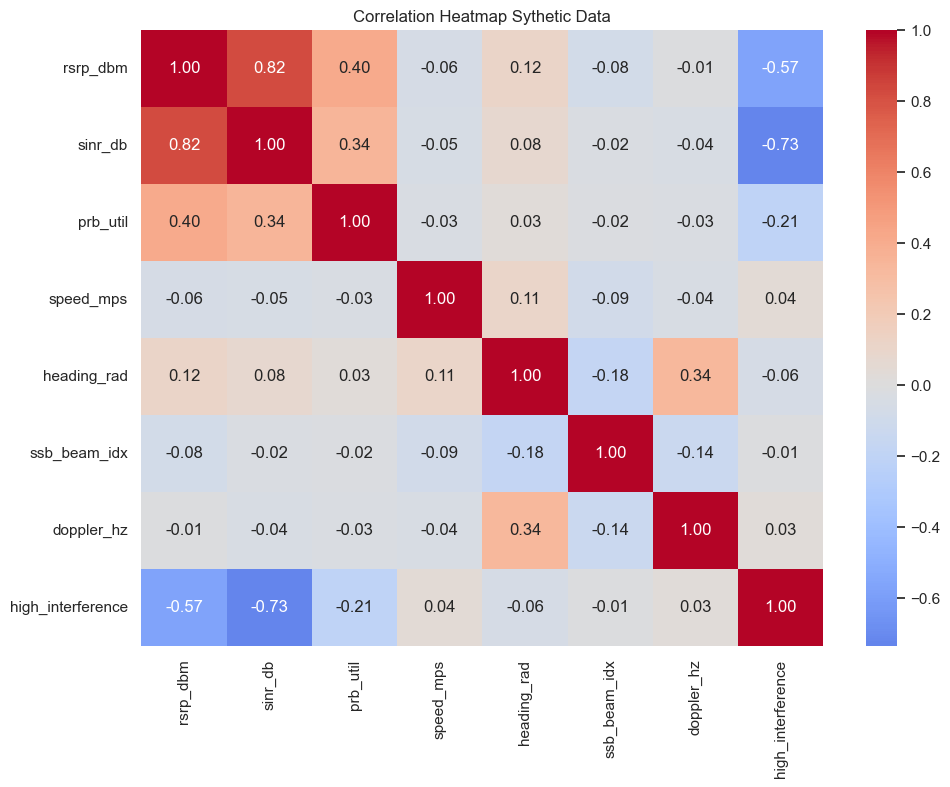

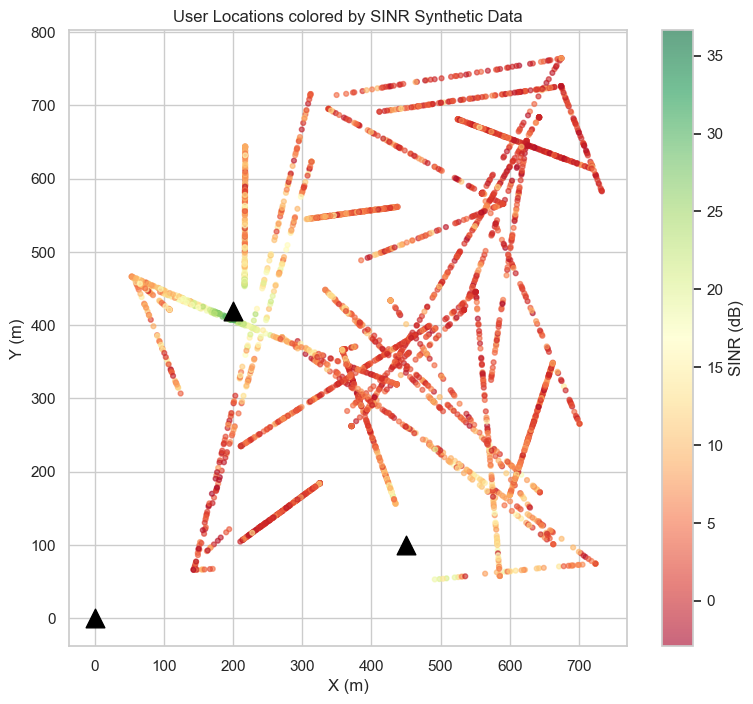

In [50]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr_cols = ["rsrp_dbm", "sinr_db", "prb_util", "speed_mps", "heading_rad", 
             "ssb_beam_idx", "doppler_hz", "high_interference"]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap Sythetic Data")
plt.show()

# Spatial plot
plt.figure(figsize=(9, 8))
sample = df.sample(min(3000, len(df)))
sc = plt.scatter(sample["x"], sample["y"], c=sample["sinr_db"], cmap="RdYlGn", alpha=0.6, s=12)
plt.colorbar(sc, label="SINR (dB)")
for bs in base_stations:
    plt.scatter(bs["x"], bs["y"], c="black", s=180, marker="^")
plt.title("User Locations colored by SINR Synthetic Data")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

BASELINE 1: Random Forest – High Interference Classification
Accuracy: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1068
   High Risk       1.00      1.00      1.00      1417

    accuracy                           1.00      2485
   macro avg       1.00      1.00      1.00      2485
weighted avg       1.00      1.00      1.00      2485



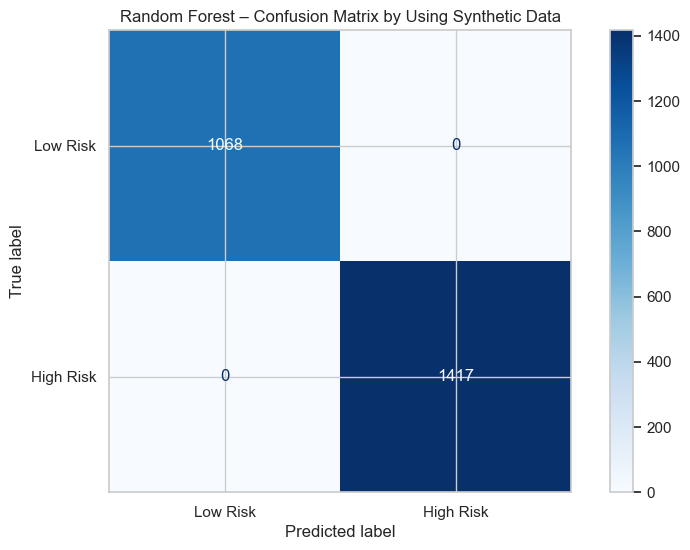

In [ ]:
# Baseline Model 1: Classification (Random Forest)


print("BASELINE 1: Random Forest – High Interference Classification")
print("="*60)

feature_cols = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz",
    "rsrp_delta", "rsrp_lag1", "sinr_lag1"
]

X = df[feature_cols]
y = df["high_interference"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Blues")
plt.title("Random Forest – Confusion Matrix ")
plt.show()

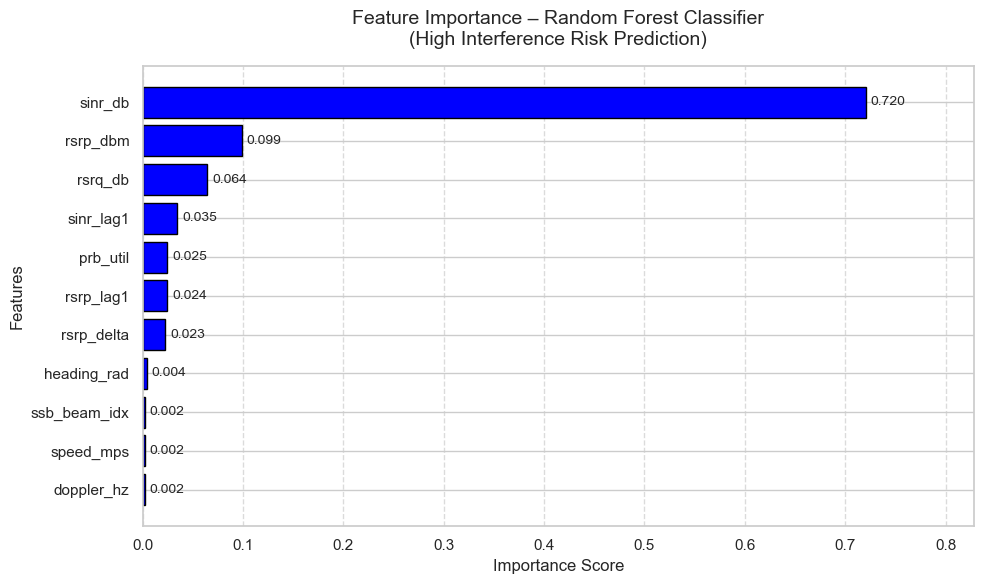

In [52]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)  # Ascending for horizontal bar plot

# Create figure
plt.figure(figsize=(10, 6))

# Horizontal bar plot
bars = plt.barh(importances.index, importances.values, color="blue", edgecolor="black")

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", va="center", fontsize=10)

plt.title("Feature Importance – Random Forest Classifier\n(High Interference Risk Prediction)", 
          fontsize=14, pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.xlim(0, importances.max() * 1.15)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [53]:
# Baseline Model 2: Beam Prediction (Linear Regression)

print("="*60)
print("BASELINE 2: Linear Regression – Next Beam Prediction")
print("="*60)

beam_features = [
    "rsrp_dbm", "rsrq_db", "sinr_db", "prb_util",
    "speed_mps", "heading_rad", "ssb_beam_idx", "doppler_hz",
    "rsrp_delta", "x", "y"
]

X_beam = df[beam_features]
y_beam = df["target_beam_idx"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_beam, y_beam, test_size=0.25, random_state=42
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

linreg = LinearRegression()
linreg.fit(X_train_b_scaled, y_train_b)

y_pred_beam = np.clip(np.round(linreg.predict(X_test_b_scaled)), 0, 63)

mae = mean_absolute_error(y_test_b, y_pred_beam)
rmse = np.sqrt(mean_squared_error(y_test_b, y_pred_beam))
r2 = r2_score(y_test_b, y_pred_beam)

print(f"MAE:  {mae:.3f} beams")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.4f}")

BASELINE 2: Linear Regression – Next Beam Prediction
MAE:  6.949 beams
RMSE: 10.197
R²:   0.3944


## Key Findings

### Exploratory Data Analysis
- **SINR** and **RSRP** are the strongest predictors of high-interference risk, confirmed by both the correlation heatmap (SINR: -0.73, RSRP: -0.57) and feature importance analysis.
- PRB utilization shows a moderate relationship with interference risk.
- Mobility-related features (Doppler, heading, and speed) have very weak correlation with the target variable.
- The spatial plot of user locations colored by SINR clearly shows that signal quality degrades as users move away from base stations, with lower SINR regions appearing between cells and near coverage edges.

## Real-World Data Validation ##

In [ ]:
# ============================================================
# 1. Load and Clean Real O-RAN Data
# ============================================================

filename = "data/neigh_measurements_1.txt"   # Change if needed

records = []
with open(filename, "r") as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            meas = data.get("RrcMeasurementReportResultInfo", {})
            serving = meas.get("ServingCellInfo", {})
            
            rsrp_raw = serving.get("SsbRsrpResult")
            rsrq_raw = serving.get("SsbRsrqResult")
            sinr_raw = serving.get("SsbSinrResult")
            
            if rsrp_raw is not None and sinr_raw is not None:
                records.append({
                    "rsrp_raw": rsrp_raw,
                    "rsrq_raw": rsrq_raw,
                    "sinr_raw": sinr_raw
                })
        except:
            continue

real_df = pd.DataFrame(records)

# Convert to approximate real units
real_df["rsrp_dbm"] = real_df["rsrp_raw"] - 156
real_df["rsrq_db"]  = (real_df["rsrq_raw"] - 40) / 2
real_df["sinr_db"]  = (real_df["sinr_raw"] / 2) - 23

# Cleaning
real_df = real_df[
    (real_df["rsrp_dbm"] >= -140) & (real_df["rsrp_dbm"] <= -40) &
    (real_df["sinr_db"]  >= -20)  & (real_df["sinr_db"]  <= 40)
].copy()
real_df["high_interference"] = ((real_df["sinr_db"] < 5) | (real_df["rsrp_dbm"] < -95)).astype(int)
real_df = real_df.dropna().reset_index(drop=True)

print("Cleaned real data shape:", real_df.shape)
print(real_df["high_interference"].value_counts(normalize=True).round(3))

Cleaned real data shape: (396322, 7)
high_interference
0    0.997
1    0.003
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 2. Prepare Common Features & Train Model
# ============================================================

common_features = ["rsrp_dbm", "rsrq_db", "sinr_db"]

X_synth = df[common_features]
y_synth = df["high_interference"]

X_train, X_test, y_train, y_test = train_test_split(
    X_synth, y_synth, test_size=0.25, random_state=42, stratify=y_synth
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf_real = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_real.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# ============================================================
# 3. Evaluate on Synthetic Test Set
# ============================================================
y_pred_synth = rf_real.predict(X_test_scaled)

print("===== Synthetic Test Set =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_synth):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_synth):.4f}")
print(classification_report(y_test, y_pred_synth, target_names=["Low Risk", "High Risk"]))

===== Synthetic Test Set =====
Accuracy : 0.9899
F1-Score : 0.9911
              precision    recall  f1-score   support

    Low Risk       0.98      1.00      0.99      1068
   High Risk       1.00      0.98      0.99      1417

    accuracy                           0.99      2485
   macro avg       0.99      0.99      0.99      2485
weighted avg       0.99      0.99      0.99      2485



In [57]:
# ============================================================
# 4. Evaluate on Real O-RAN Data (Default Threshold = 0.5)
# ============================================================
X_real = real_df[common_features]
y_real = real_df["high_interference"]
X_real_scaled = scaler.transform(X_real)

y_pred_real = rf_real.predict(X_real_scaled)

print("===== Real O-RAN Data (Threshold = 0.5) =====")
print(f"Accuracy : {accuracy_score(y_real, y_pred_real):.4f}")
print(f"F1-Score : {f1_score(y_real, y_pred_real):.4f}")
print(classification_report(y_real, y_pred_real, target_names=["Low Risk", "High Risk"]))

===== Real O-RAN Data (Threshold = 0.5) =====
Accuracy : 0.9988
F1-Score : 0.7096
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00    395241
   High Risk       1.00      0.55      0.71      1081

    accuracy                           1.00    396322
   macro avg       1.00      0.78      0.85    396322
weighted avg       1.00      1.00      1.00    396322



===== Real O-RAN Data (Threshold = 0.3) =====
Accuracy : 0.4254
F1-Score : 0.0054
              precision    recall  f1-score   support

    Low Risk       1.00      0.42      0.60    395241
   High Risk       0.00      0.57      0.01      1081

    accuracy                           0.43    396322
   macro avg       0.50      0.50      0.30    396322
weighted avg       0.99      0.43      0.59    396322



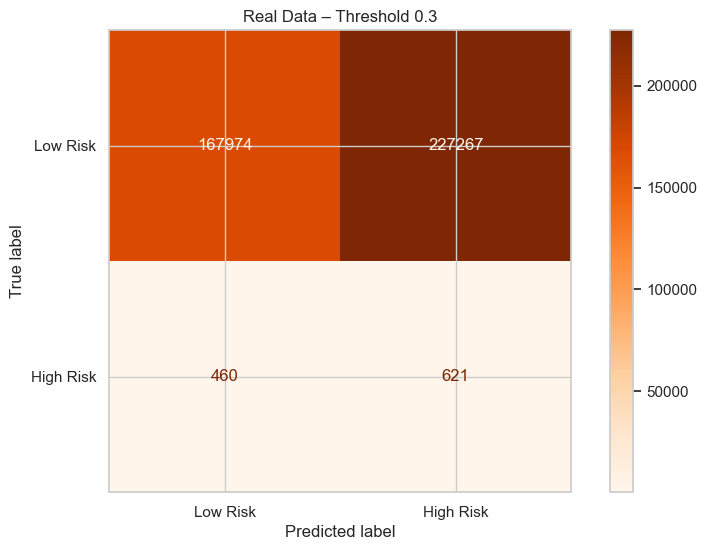

In [58]:
# ============================================================
# 5. Adjust Decision Threshold
# ============================================================
y_proba = rf_real.predict_proba(X_real_scaled)[:, 1]
threshold = 0.30
y_pred_adjusted = (y_proba >= threshold).astype(int)

print(f"===== Real O-RAN Data (Threshold = {threshold}) =====")
print(f"Accuracy : {accuracy_score(y_real, y_pred_adjusted):.4f}")
print(f"F1-Score : {f1_score(y_real, y_pred_adjusted):.4f}")
print(classification_report(y_real, y_pred_adjusted, target_names=["Low Risk", "High Risk"]))

cm = confusion_matrix(y_real, y_pred_adjusted)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
disp.plot(cmap="Oranges")
plt.title(f"Real Data – Threshold {threshold}")
plt.show()

 Threshold  Accuracy  Precision  Recall  F1-Score
      0.20    0.1091     0.0031  1.0000    0.0061
      0.25    0.1338     0.0018  0.5745    0.0036
      0.30    0.4254     0.0027  0.5745    0.0054
      0.35    0.9970     0.4528  0.5504    0.4969
      0.40    0.9987     0.9835  0.5504    0.7058
      0.45    0.9988     0.9983  0.5504    0.7096
      0.50    0.9988     0.9983  0.5504    0.7096


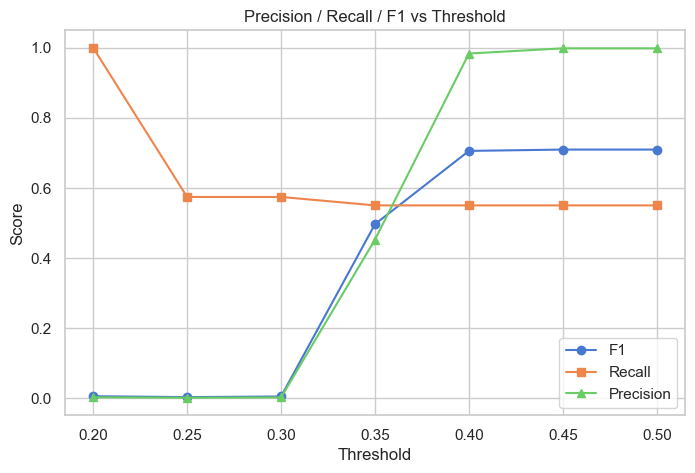

In [ ]:
# ============================================================
# 6. Test Multiple Thresholds
# ============================================================

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        "Threshold": t,
        "Accuracy": round(accuracy_score(y_real, y_pred_t), 4),
        "Precision": round(precision_score(y_real, y_pred_t), 4),
        "Recall": round(recall_score(y_real, y_pred_t), 4),
        "F1-Score": round(f1_score(y_real, y_pred_t), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(results_df["Threshold"], results_df["F1-Score"], marker='o', label="F1")
plt.plot(results_df["Threshold"], results_df["Recall"], marker='s', label="Recall")
plt.plot(results_df["Threshold"], results_df["Precision"], marker='^', label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

After testing multiple thresholds, a threshold of 0.40 – 0.45 provides the best balance between Precision and Recall on the real O-RAN data. Lower thresholds significantly increase false alarms, while higher thresholds maintain high precision with acceptable recall.

## Key Findings

### Exploratory Data Analysis
- **SINR** and **RSRP** are the strongest predictors of high-interference risk, confirmed by both the correlation heatmap (SINR: -0.73, RSRP: -0.57) and feature importance analysis.
- PRB utilization shows a moderate relationship with interference risk.
- Mobility-related features (Doppler, heading, and speed) have very weak correlation with the target variable.
- The spatial plot of user locations colored by SINR clearly shows that signal quality degrades as users move away from base stations, with lower SINR regions appearing between cells and near coverage edges.

### Baseline Model Performance (Synthetic Data)
- The Random Forest classifier achieved excellent performance on the synthetic test set.
- Multiple Linear Regression provided a reasonable baseline for predicting the next beam index.
- Feature importance results aligned well with the correlation analysis, highlighting SINR and RSRP as the most influential features.

### Real-World Validation
- A clear sim-to-real performance gap was observed when evaluating the model on real O-RAN data.
- At the default threshold (0.5), the model achieved high precision but moderate recall.
- After testing multiple thresholds, the best balance between precision and recall was found around **0.40 – 0.45**.
- Lower thresholds (e.g., 0.30) generated too many false alarms and are not recommended.

### Conclusion
- The model is conservative but reliable — when it predicts a user is at high risk, it is usually correct.
- Despite the sim-to-real gap, the model demonstrates useful predictive capability for proactive interference detection.
- Future improvements can be achieved by fine-tuning the model on real O-RAN measurements.